In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.optimize import curve_fit
import scipy.special as sp
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from scipy.special import gamma
font = {'size': 30, 'weight':'normal'}
plt.rc('font', **font)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "text.latex.preamble": r"\usepackage{amssymb}",
})
rng = np.random.default_rng(seed=42)
colors = [['blue',"slateblue"], ['darkgoldenrod', "goldenrod"], ['olivedrab', "yellowgreen"], ['red', "indianred",], ['plum',"pink"], ['black','dimgray'], ['orangered','coral'] ]

# SATW Figures with Leo Data

220000
220000
220000


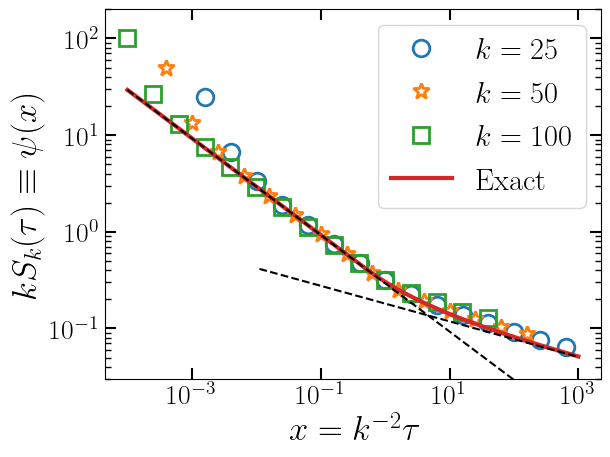

In [90]:
dw=2
beta=1
phi = 1/np.e
theta=np.exp(-beta)/2
i=0
Marker=['o','*','s']
fig,ax=plt.subplots(1,1)
for x0 in [25,50,100]:
    Times=np.logspace(0,6,16)[:-1]
    Ti=[]
    for s in os.listdir('Data/SATRW_1e6/'+str(x0)):
        Ti+=list(np.load('Data/SATRW_1e6/'+str(x0)+'/'+s))
    print(len(Ti))
    Ti=np.array(Ti)
    Ti=Ti[Ti>0]
    Sl=np.array([np.sum(Ti>=ti)/len(Ti) for ti in Times])
    plt.plot(Times/x0**dw,x0*Sl,Marker[i],markersize=12,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0,label=f'$k={x0}$')
    #if i==2:
        #plt.plot(Times/x0**dw,(Times/Times[len(Times)//4])**(-1/dw)*Sl[len(Times)//4]*x0,'--r',linewidth=4)
    #if i==0:
        #plt.plot(Times[len(Times)//4:]/x0**dw,(Times[len(Times)//4:]/Times[len(Times)//4*3])**(-theta)*Sl[len(Times)//4*3]*x0,'--k',linewidth=4)
    i+=1




s_th = np.loadtxt('Data/s-phi0.367879.csv')
tau_th = np.loadtxt('Data/tau-phi0.367879.csv')

asymp_largex = (2/tau_th)**(phi/2) * sp.gamma((1+phi)/2) / (np.sqrt(np.pi) * sp.beta(phi,phi))
asymp_smallx = phi * np.sqrt(2/np.pi/tau_th)

plt.semilogx()
plt.semilogy()

plt.loglog(tau_th,s_th,linewidth=3,label=r'$\mathrm{Exact}$')
plt.loglog(tau_th[tau_th>.01], asymp_largex[tau_th>.01], '--k')
plt.loglog(tau_th, asymp_smallx, '--k')
# ax.semilogx()
# ax.semilogy()

import matplotlib.ticker as mticker

# Major ticks at powers of 10
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))

# Minor ticks at 2..9 between powers of 10
subs = np.arange(2, 10) * 0.1
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))

# Clean tick labels (10^n style)
ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

# Tick appearance
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5)
ax.tick_params(axis='both', which='minor', length=4, width=1.0)

# Ticks on all sides (nice for publications)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_ylim(3e-2,2e2)
plt.xlabel(r'$x=k^{-2} \tau$',fontsize=25)
plt.ylabel(r'$k S_k(\tau) \equiv \psi(x)$',fontsize=25)
plt.legend(fontsize=22,loc='upper right')

plt.savefig('Figures/SATW-phiem1.pdf', dpi=600,bbox_inches='tight')

plt.show()

20000
20000
20000


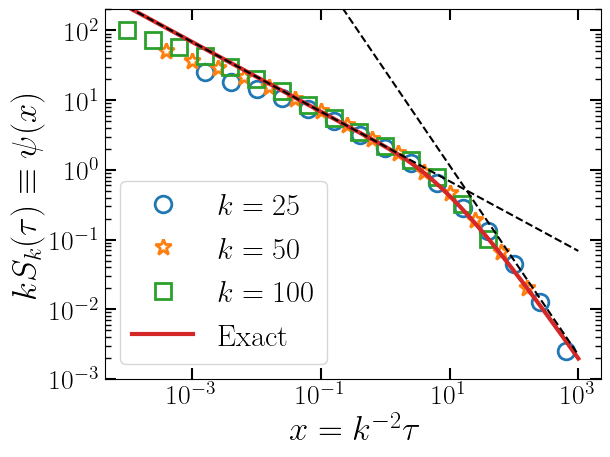

In [83]:
dw=2
phi = np.e
beta=-1
theta=np.exp(-beta)/2
i=0
Marker=['o','*','s']
fig,ax=plt.subplots(1,1)

for x0 in [25,50,100]:
    Times=np.logspace(0,6,16)[:-1]
    Ti=[]
    for s in os.listdir('Data/SATRW_m1_1e6/'+str(x0)):
        Ti+=list(np.load('Data/SATRW_m1_1e6/'+str(x0)+'/'+s))
    print(len(Ti))
    Ti=np.array(Ti)
    Ti=Ti[Ti>0]
    Sl=np.array([np.sum(Ti>=ti)/len(Ti) for ti in Times])
    plt.plot(Times/x0**dw,x0*Sl,Marker[i],markersize=12,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0,label=f'$k={x0}$')
    # if i==2:
    #     Ti=np.logspace(0,7,10)
    #     plt.plot(Ti/x0**dw,(Ti/Times[len(Times)//4])**(-1/dw)*Sl[len(Times)//4]*x0,'--r',linewidth=4)
    # if i==0:
    #     Ti=np.logspace(2,6,10)
    #     plt.plot(Ti/x0**dw,(Ti/Times[len(Times)//4*3+2])**(-theta)*Sl[len(Times)//4*3+2]*x0,'--k',linewidth=4)
    i+=1

s_th = np.loadtxt('Data/s-phiE.csv')
tau_th = np.loadtxt('Data/tau-phiE.csv')

asymp_largex = (2/tau_th)**(phi/2) * sp.gamma((1+phi)/2) / (np.sqrt(np.pi) * sp.beta(phi,phi))
asymp_smallx = phi * np.sqrt(2/np.pi/tau_th)

plt.xlabel(r'$\tau/k^{d_w}$',fontsize=25)
plt.ylabel(r'$k S_k(\tau)$',fontsize=25)
ax.loglog()

plt.loglog(tau_th,s_th,linewidth=3,label=r'$\mathrm{Exact}$')
plt.loglog(tau_th[tau_th>.01], asymp_largex[tau_th>.01], '--k')
plt.loglog(tau_th, asymp_smallx, '--k')
# ax.semilogx()
# ax.semilogy()

import matplotlib.ticker as mticker

# Major ticks at powers of 10
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))

# Minor ticks at 2..9 between powers of 10
subs = np.arange(2, 10) * 0.1
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))

# Clean tick labels (10^n style)
ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

# Tick appearance
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5)
ax.tick_params(axis='both', which='minor', length=4, width=1.0)

# Ticks on all sides (nice for publications)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.set_ylim(1e-3,2e2)
plt.xlabel(r'$x=k^{-2} \tau$',fontsize=25)
plt.ylabel(r'$k S_k(\tau) \equiv \psi(x)$',fontsize=25)
plt.legend(fontsize=22,loc='lower left')

#ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.savefig('Figures/SATW-phie.pdf', dpi=600,bbox_inches='tight')

plt.show()

# Simus for nonzero saturation

In [96]:
L_bound = 10000
N_samples = 500000
alpha = 3
beta=1/6
alldir = np.array([-1, 1], dtype=np.int64)
tmax=1e7

@njit
def weight(n,phi):
    # sigmoid starting at 1/phi and ending at 1
    return 1/phi + (1-1/phi) * (2/(1 + np.exp(-n)) - 1)

@njit
def jump_sigmoid(trace, w, phi):
    # returns the direction of the jump given the walker's neighboring edge local time
    # here we assume that the weight function saturates but is not a heaviside theta, and that we use the edge convention.
    # also here we assume alpha = beta for symmetric SATW.
    visits_left = trace[w,0]+trace[w-1,1]
    visits_right = trace[w,1]+trace[w+1,0]
    norm = weight(visits_left,phi) + weight(visits_right,phi)
    probs = np.array([weight(visits_left,phi)/norm,weight(visits_right,phi)/norm])
    pc = np.cumsum(probs)
    v= np.random.rand()
    new_dir = alldir[(v<pc).argmax(axis=0)]
    
    return new_dir

@njit
def sim_records(k): 
    trace = np.zeros((L_bound,2)) # trace[x,0 (resp 1)] gives number of times the walker has traversed the oriented edge (x-1,x) (resp (x,x+1))
    pos=L_bound//2
    current_max = pos
    tau = 0
    count_tau = False
    n = 0
    # hard cutoff needed
    while (current_max != k+1+L_bound//2) and n<tmax:
        if (current_max == k+L_bound//2):
            count_tau = True
        # asymmetry
        if pos >L_bound//2:
            dir = jump_sigmoid(trace,pos,beta)
        else:
            dir = jump_sigmoid(trace,pos,alpha)

        trace[pos, (dir+1)//2] += 1
        pos += dir

        if count_tau:
            tau+=1

        if pos>current_max:
            current_max=pos
        n+=1

    return tau

def samples_records(k):
    tau = np.empty(N_samples, dtype=np.int64)
    for i in range(N_samples):
        if i % 1000 == 0:
            print(i)
        tau[i]=sim_records(k)
    return tau

In [97]:
k_list = [25,50,100]
for k in k_list:
    print(k)
    simresults = samples_records(k)
    np.save(f"Data/records-sigmoid-asym-alpha{alpha}-beta{beta}-k{k}.npy",simresults)

25
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
101000
102000
103000
104000
105000
106000
107000
108000
109000
110000
111000
112000
113000
114000
115000
116000
117000
118000
119000
120000
121000
122000
123000
124000
125000
126000
127000
128000
129000
130000
131000
132000
133000
134000
135000
136000
137000
138000
139000
140000
141000
142000
143000
144000
145000
146000
147000
148000
149000
150000
151000
152000
153000
154000
155000
156000
157000
1580

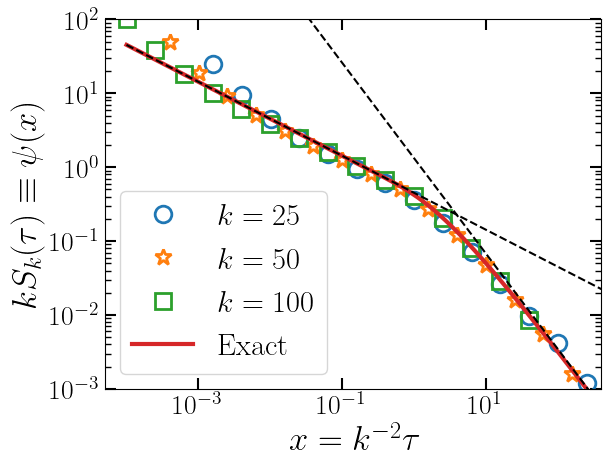

In [99]:
dw=2
alpha_eff = 2.5803924616081577
beta_eff = 0.5662560875234257
fig,ax=plt.subplots(1,1)



ax.set_xlim(0.00005,4e2)
ax.set_ylim(1e-3,100)
Marker=['o','*','s']
for i, x0 in enumerate([25,50,100]):
    Times=np.logspace(0,6,16)[:-1]
    Ti=np.load(f'Data/records-sigmoid-asym-alpha3-beta0.16666666666666666-k{x0}.npy')
    # Ti = Ti[Ti<tmax]
    Sl=np.array([np.sum(Ti>=ti)/len(Ti) for ti in Times])
    plt.loglog(Times/x0**dw,x0*Sl,Marker[i],markersize=12,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0,label=f'$k={x0}$')
    i+=1

s_th = np.loadtxt('Data/s-phi-nonzerosat-alpha3-beta1over6.csv')
tau_th = np.loadtxt('Data/tau-phi-nonzerosat-alpha3-beta1over6.csv')

asymp_largex = (2/tau_th)**(alpha_eff/2) * sp.gamma((1+alpha_eff)/2) / (np.sqrt(np.pi) * sp.beta(alpha_eff,beta_eff))
asymp_smallx = beta_eff * np.sqrt(2/np.pi/tau_th)

plt.loglog(tau_th,s_th,linewidth=3,label=r'$\mathrm{Exact}$')
plt.loglog(tau_th[tau_th>.01], asymp_largex[tau_th>.01], '--k')
plt.loglog(tau_th, asymp_smallx, '--k')
# ax.semilogx()
# ax.semilogy()

import matplotlib.ticker as mticker

# Major ticks at powers of 10
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))

# Minor ticks at 2..9 between powers of 10
subs = np.arange(2, 10) * 0.1
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))

# Clean tick labels (10^n style)
ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

# Tick appearance
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5)
ax.tick_params(axis='both', which='minor', length=4, width=1.0)

# Ticks on all sides (nice for publications)
ax.tick_params(which='both', direction='in', top=True, right=True)

plt.xlabel(r'$x=k^{-2} \tau$',fontsize=25)
plt.ylabel(r'$k S_k(\tau) \equiv \psi(x)$',fontsize=25)
plt.legend(fontsize=22,loc='lower left')

plt.savefig('Figures/SATW-nonzerosat-asym-alpha3-beta1over6.pdf', dpi=600,bbox_inches='tight')
plt.show()

# Correlations between record ages

Careful: MANY samples needed + dont set the threshold age too low.

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.special import gamma

import numpy as np
from numba import njit


@njit
def sample_qplus(alpha, beta, k):
    """
    Sample m from
        q_+(m,k) = k^alpha m^(beta-1)
                   / [B(alpha,beta) (k+m)^(alpha+beta)].

    Equivalently u=k/(k+m) ~ Beta(alpha,beta).
    """
    ga = np.random.gamma(alpha, 1.0)
    gb = np.random.gamma(beta, 1.0)
    u = ga / (ga + gb)

    m = k * (1.0 - u) / u

    # Interface with the discrete SATW simulation
    return max(0, int(np.rint(m)))


@njit
def sample_qplus2(alpha, beta, k1, m1, k2):
    """
    Sample m2 from q_+^(2)(k2,m2,s=0 | k1,m1).

    This samples the analytical transition law of the minimum.
    No SATW trajectory between k1 and k2 is generated.
    """
    x = float(k1)
    m = float(m1)

    while True:

        # Next change of the minimum.
        #
        # P(no change of m between x and y)
        # = ((x+m)/(y+m))^beta.
        u = np.random.random()
        if u == 0.0:
            u = 1e-300

        xjump = (x + m) * u**(-1.0 / beta) - m

        # No change of minimum before reaching k2
        if xjump >= k2:
            return max(0, int(np.rint(m)))

        # At xjump, draw the new minimum:
        #
        # (xjump + m_new)/(xjump + m)
        # has Pareto tail of exponent alpha.
        v = np.random.random()
        if v == 0.0:
            v = 1e-300

        span_new = (xjump + m) * v**(-1.0 / alpha)
        m = span_new - xjump

        x = xjump


@njit
def simulate_one_age(alpha, beta, k, m):
    x = k
    xmin = -m
    t = 0

    while (x != k + 1) and (t < (1e5)*(k**2)):
        r = np.random.random()

        if x == k:
            # positive boundary
            if r < 1.0 / (1.0 + beta):
                x += 1
            else:
                x -= 1

        elif x == xmin:
            # negative boundary
            if r < 1.0 / (1.0 + alpha):
                x -= 1
            else:
                x += 1

        else:
            # bulk
            if r < 0.5:
                x += 1
            else:
                x -= 1

        t += 1

        if x < xmin:
            xmin = x

    return t, -xmin


@njit
def sample_ages(alpha, beta, k, l, N=100000, seed=0):
    np.random.seed(seed)

    tau_k = np.empty(N, dtype=np.int64)
    tau_l = np.empty(N, dtype=np.int64)

    progress_step = max(1, N // 100)

    for n in range(N):

        if n % progress_step == 0:
            print(n / N)

        # ---------------------------------------------------------
        # 1. Instantly reach k and sample the corresponding minimum
        # ---------------------------------------------------------
        m_k = sample_qplus(alpha, beta, k)

        # ---------------------------------------------------------
        # 2. Really simulate ONLY k -> k+1
        # ---------------------------------------------------------
        tk, m_kp1 = simulate_one_age(alpha, beta, k, m_k)

        # ---------------------------------------------------------
        # 3. Instantly reach l.
        #
        # Important: condition on m_{k+1}, not m_k, because the
        # actual tau_k trajectory may itself have changed the minimum.
        # ---------------------------------------------------------
        if l == k + 1:
            m_l = m_kp1
        else:
            m_l = sample_qplus2(
                alpha, beta,
                k + 1, m_kp1,
                l
            )

        # ---------------------------------------------------------
        # 4. Really simulate ONLY l -> l+1
        # ---------------------------------------------------------
        tl, _ = simulate_one_age(alpha, beta, l, m_l)

        tau_k[n] = tk
        tau_l[n] = tl

    return tau_k, tau_l


alpha = beta = 2
k, l = 4,5
N = 200_000_00 # nb of samples

tk, tl = sample_ages(alpha, beta, k, l, N=N)

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


In [5]:
# alpha=beta=2
farray2=np.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.999999, 0.999995, 0.999977, \
0.999902, 0.999656, 0.998982, 0.99739, 0.994111, 0.988124, 0.978293, \
0.963578, 0.943252, 0.917044, 0.885167, 0.848249, 0.807202, 0.76308, \
0.716962, 0.669863, 0.622681, 0.576175, 0.530955, 0.487488, 0.446113, \
0.407059, 0.370458, 0.33637, 0.304791, 0.275672, 0.24893, 0.224459])
xarray2=np.array([0.01, 0.0125893, 0.0158489, 0.0199526, 0.0251189, 0.0316228, \
0.0398107, 0.0501187, 0.0630957, 0.0794328, 0.1, 0.125893, 0.158489, \
0.199526, 0.251189, 0.316228, 0.398107, 0.501187, 0.630957, 0.794328, \
1., 1.25893, 1.58489, 1.99526, 2.51189, 3.16228, 3.98107, 5.01187, \
6.30957, 7.94328, 10., 12.5893, 15.8489, 19.9526, 25.1189, 31.6228, \
39.8107, 50.1187, 63.0957, 79.4328, 100.])
# alpha=beta=1/2
xarrayonehalf=np.array([0.01, 0.0158489, 0.0251189, 0.0398107, 0.0630957, 0.1, 0.158489, \
0.251189, 0.398107, 0.630957, 1., 1.58489, 2.51189, 3.98107, 6.30957, \
10., 15.8489, 25.1189, 39.8107, 63.0957, 100.])
farrayonehalf=np.array([1., 1., 1., 1., 1., 1., 1., 1., 1.00005, 1.0004, 1.00189, 1.00646, \
1.01696, 1.03634, 1.06691, 1.11019, 1.1673, 1.23932, 1.32737, \
1.43276, 1.55696])

In [6]:
# k=1, l=2, alpha=1/2=beta
tkonehalf = np.load(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tk-alpha-onehalf.npy")
tlonehalf = np.load(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tl-alpha-onehalf.npy")
# k=5,l=8, alpha=beta=2
tk2 = np.load(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tk-alpha2.npy")
tl2 = np.load(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tl-alpha2.npy")

In [7]:
@njit
def comp(tau, taup, tk, tl):
    R = np.zeros(taup.size)
    Sk = np.mean(tk>= tau)
    for (i,tp) in enumerate(taup):
        print(i/taup.size)
        Sl  = np.mean(tl >= tp)
        Skl = np.mean((tk >= tau) & (tl >= tp))
        R[i]=Skl/(Sk*Sl)
    return R

alpha=2
beta=2
k=5
l=8
p = (alpha - 1)/2
K = beta * gamma(alpha)*gamma(beta) / gamma(alpha+beta) / (2**p * gamma((alpha+1)/2))

tau2 = 1000*k**2
taup2 = xarray2*tau2

prediction2 = farray2 * K * (taup2/l**2)**p

R2=comp(tau2, taup2, tk2, tl2)

alpha=1/2
beta=1/2
k=1
l=2
p = (alpha - 1)/2
K = beta * gamma(alpha)*gamma(beta) / gamma(alpha+beta) / (2**p * gamma((alpha+1)/2))

tauonehalf = 1000*k**2
tauponehalf = xarrayonehalf*tauonehalf

predictiononehalf = farrayonehalf * K * (tauponehalf/l**2)**p

Ronehalf=comp(tauonehalf, tauponehalf, tkonehalf, tlonehalf)

0.0
0.024390243902439025
0.04878048780487805
0.07317073170731707
0.0975609756097561
0.12195121951219512
0.14634146341463414
0.17073170731707318
0.1951219512195122
0.21951219512195122
0.24390243902439024
0.2682926829268293
0.2926829268292683
0.3170731707317073
0.34146341463414637
0.36585365853658536
0.3902439024390244
0.4146341463414634
0.43902439024390244
0.4634146341463415
0.4878048780487805
0.5121951219512195
0.5365853658536586
0.5609756097560976
0.5853658536585366
0.6097560975609756
0.6341463414634146
0.6585365853658537
0.6829268292682927
0.7073170731707317
0.7317073170731707
0.7560975609756098
0.7804878048780488
0.8048780487804879
0.8292682926829268
0.8536585365853658
0.8780487804878049
0.9024390243902439
0.926829268292683
0.9512195121951219
0.975609756097561
0.0
0.047619047619047616
0.09523809523809523
0.14285714285714285
0.19047619047619047
0.23809523809523808
0.2857142857142857
0.3333333333333333
0.38095238095238093
0.42857142857142855
0.47619047619047616
0.5238095238095238
0.57

C:\Users\julie\AppData\Local\Temp\ipykernel_16504\3450982370.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.loglog(xarrayonehalf, predictiononehalf, '--k', lw=2.5, color=colors[0][0])


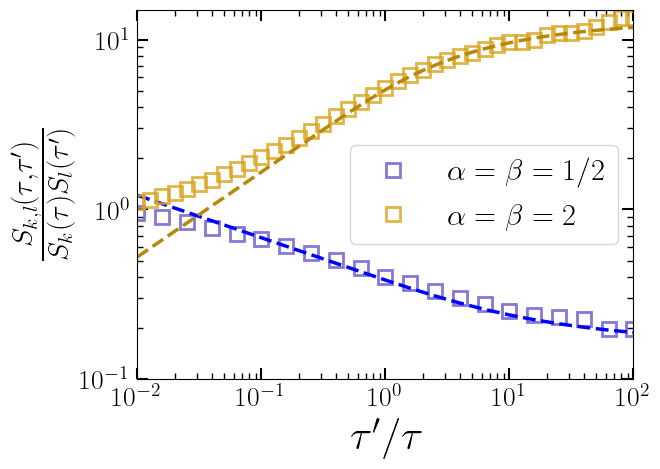

In [24]:
fig,ax=plt.subplots(1,1)

plt.loglog(tauponehalf/tauonehalf, Ronehalf, 's',markersize=10,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0, color=colors[0][1],label=r"$\alpha=\beta=1/2$",alpha=.82)

plt.loglog(xarrayonehalf, predictiononehalf, '--k', lw=2.5, color=colors[0][0])

plt.loglog(taup2/tau2, R2, 's',markersize=10,linestyle='',fillstyle='none',linewidth=20,markeredgewidth=2.0, color=colors[1][1],label=r"$\alpha=\beta=2$",alpha=.82)

plt.loglog(xarray2, prediction2, '--', lw=2.5, color=colors[1][0])

ax.set_ylim(1e-1, 15)
ax.set_xlim(1e-2, 1e2)

# ax.axvline(seuil, color='red', ls= '-.')

import matplotlib.ticker as mticker

# Major ticks at powers of 10
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0))

# Minor ticks at 2..9 between powers of 10
subs = np.arange(2, 10) * 0.1
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=subs))

# Clean tick labels (10^n style)
ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

# Tick appearance
ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.5,pad=5)
ax.tick_params(axis='both', which='minor', length=4, width=1.0)

# Ticks on all sides (nice for publications)
ax.tick_params(which='both', direction='in', top=True, right=True)

plt.xlabel(r"$\tau'/\tau$")
plt.ylabel(r"$\frac{S_{k,l}(\tau,\tau')}{S_k(\tau)S_l(\tau')}$")
plt.legend(fontsize=22)

plt.savefig(f'Figures/SATW-correlations-alpha2k5l8-alphaonehalfk1l2.pdf', dpi=600,bbox_inches='tight')
plt.show()

In [ ]:
# np.save(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tk-alpha-onehalf.npy", tk)
# np.save(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tl-alpha-onehalf.npy", tl)
np.save(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tk-alpha-2.npy", tk)
np.save(f"C:\\Users\\julie\\Desktop\\data_corr_records\\tl-alpha-2.npy", tl)


# Explaining the correlation mechanism for $\alpha>1$

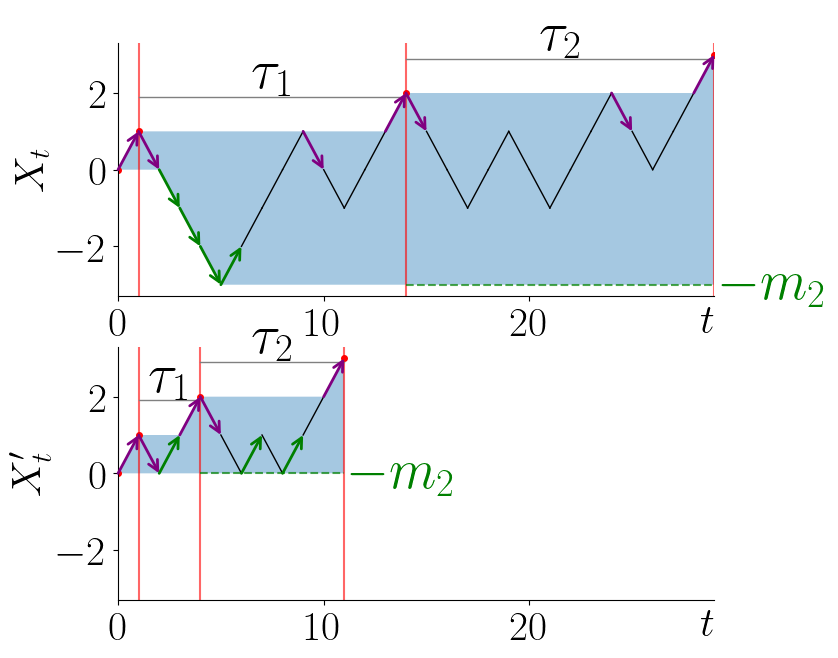

In [87]:
import numpy as np
import matplotlib.pyplot as plt

font = {'size': 30, 'weight': 'normal'}
plt.rc('font', **font)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

# ------------------------------------------------------------
# Hand-picked trajectories
# Top: long tau_1 -> deep minimum m_2 -> larger tau_2, no hit of m_2
# Bottom: short tau_1 -> shallow minimum m_2=0 -> multiple reflections during tau_2
# ------------------------------------------------------------

# Long tau_1 -> distant m_2=-3 -> long tau_2 with NO reflection at m_2
X1 = np.array([
    0, 1,
    0, -1, -2, -3, -2, -1, 0, 1, 0, -1, 0, 1, 2,
    1, 0, -1, 0, 1, 0, -1, 0, 1, 2, 1, 0, 1, 2, 3
])

# Short tau_1 -> close m_2=0 -> short tau_2 with TWO reflections at m_2
X2 = np.array([
    0, 1,
    0, 1, 2,
    1, 0, 1,     # reflection 1: 0 -> 1
    0, 1,        # reflection 2: 0 -> 1
    2, 3
])

fig, axes = plt.subplots(2, 1, figsize=(8.2, 6.4), sharey=True)

def draw_walk(ax, X):
    t = np.arange(len(X))
    runmax = np.maximum.accumulate(X)
    runmin = np.minimum.accumulate(X)

    global_max_mask = (X == runmax)
    global_min_mask = (X == runmin)

    records_max = np.where(np.diff(np.maximum.accumulate(X), prepend=-np.inf) > 0)[0]

    ax.fill_between(t, runmin, runmax, alpha=.4)

    # Draw steps with same color code as Fig. 1
    for i in range(len(t)-1):
        start_x, start_y = t[i], X[i]
        end_x, end_y = t[i+1], X[i+1]

        if global_max_mask[i]:
            ax.annotate(
                '', xy=(end_x, end_y), xytext=(start_x, start_y),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0)
            )
        elif global_min_mask[i]:
            ax.annotate(
                '', xy=(end_x, end_y), xytext=(start_x, start_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=2,
                                mutation_scale=18, shrinkA=0, shrinkB=0)
            )
        else:
            ax.plot([start_x, end_x], [start_y, end_y], color='black', lw=1)

    # Red dots: new maxima
    ax.plot(records_max, X[records_max], 'o', color='red', ms=4)

    # We display tau_1 = T_2-T_1 and tau_2 = T_3-T_2
    T1, T2, T3 = records_max[1:4]

    # Vertical record lines
    for T in [T1, T2, T3]:
        ax.axvline(T, color='red', alpha=.6)

    # Holding time annotations
    h = 0.9
    y1 = X[T1]
    y2 = X[T2]

    ax.plot([T1, T2], [y1 + h, y1 + h], color='gray', lw=1)
    ax.text((T1 + T2)/2, y1 + h + 0.25, r"$\tau_1$", ha="center",fontsize=40)

    ax.plot([T2, T3], [y2 + h, y2 + h], color='gray', lw=1)
    ax.text((T2 + T3)/2, y2 + h + 0.25, r"$\tau_2$", ha="center",fontsize=40)

    # Inherited minimum after reaching record 2
    m2 = np.min(X[:T2+1])
    ax.hlines(m2, T2, T3, color='green', alpha=.7, ls='--', lw=1.5)
    ax.text(T3 + 0.3, m2, r"$-m_2$", color='green', va='center',fontsize=40)

    # ax.text(0.02, 0.92, panel_label, transform=ax.transAxes)

    # ax.set_xlim(0, len(X)-1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xticks([])
    ax.set_yticks([-2,0,2])
    ax.set_xlabel(r"$t$", loc='right', labelpad=-30)

draw_walk(axes[0], X1)
draw_walk(axes[1], X2)

axes[0].set_ylabel(r"$X_t$")
axes[1].set_ylabel(r"$X_t'$")

Tmax = max(len(X1), len(X2)) - 1

# after calling draw_walk(...)
for ax in axes:
    ax.set_xlim(0, Tmax)

plt.tight_layout(pad=0.01, h_pad=0.01)
fig.subplots_adjust(hspace=0.2)
plt.savefig("./Figures/tau1_tau2_schematic.pdf", dpi=600, bbox_inches='tight')
plt.show()